# seaborn

A self-contained refresher on **seaborn** — the statistical-plotting layer that sits on top of
Matplotlib and speaks tidy DataFrames.

**Domain:** Data Analysis & Research  ·  **recommended addition**  ·  **runnable:** yes

## 1. What & Why

**seaborn** is a high-level plotting library built on top of Matplotlib. You hand it a *tidy*
pandas DataFrame and the *names* of columns to map onto x, y, color, size, and facets — and it
does the statistical aggregation, color palettes, legends, and axis labels for you.

The problem it solves: making a publication-quality statistical chart in raw Matplotlib means
manually grouping data, computing means and confidence intervals, looping to draw each category,
building the legend by hand, and styling every spine. seaborn collapses that to one function call
where you describe the *mapping*, not the drawing.

**Reach for it when** you have tabular data in a DataFrame and want to *explore relationships* —
distributions, category comparisons, correlations, trends with uncertainty — quickly and with
sane defaults. It is the de-facto EDA tool for data scientists.

**Don't reach for it when** you need pixel-level control of a bespoke figure (drop to Matplotlib),
interactive/zoomable web charts (use Plotly or Altair), or you're plotting non-tabular data like
raw images or 3-D meshes. seaborn is a convenience layer — anything it draws, you can still tweak
with the underlying Matplotlib `Axes`.

## 2. Mental Model

**seaborn is a grammar-of-graphics *mapping* engine; Matplotlib is the renderer underneath.**

You never say "draw a blue dot at (3, 5)." You say: *"x is `flipper_len`, y is `body_mass`,
color is `species`, and split into one panel per `island`."* seaborn groups the rows, picks a
palette, estimates any statistics (means, CIs, regression lines, KDEs), and emits Matplotlib
artists.

Two layers of function, and knowing which you're calling is *the* key to the library:

```
  Figure-level  (own the whole figure, can facet into a grid)
  ├─ relplot   → scatter / line          (backed by FacetGrid)
  ├─ displot   → hist / kde / ecdf
  ├─ catplot   → box / violin / bar / strip ...
  └─ lmplot    → regression
        │  returns a FacetGrid; use `col=`, `row=` to make small multiples
        ▼
  Axes-level    (draw into ONE matplotlib Axes you can compose/subplot)
  ├─ scatterplot, lineplot
  ├─ histplot, kdeplot, ecdfplot
  ├─ boxplot, violinplot, barplot, stripplot ...
  └─ regplot, heatmap
        │  returns a matplotlib Axes; pass `ax=` to place it
        ▼
              Matplotlib  (Figure / Axes / artists)
```

Same data, two doors: `displot(...)` is the figure-level wrapper around the axes-level
`histplot(...)`. Faceting → figure-level. Composing into your own subplot grid → axes-level.

## 3. Key Concepts

- **Tidy / long-form data** — one row per observation, one column per variable. seaborn assumes
  this. Wide tables (a column per group) often need `df.melt()` first.
- **Semantic mappings** — `x`, `y`, `hue` (color), `size`, `style`, `col`/`row` (facets). You
  pass *column names* and the `data=` frame; seaborn resolves them.
- **Figure-level vs axes-level** — figure-level functions (`relplot`, `displot`, `catplot`,
  `lmplot`) own a whole figure and can facet; axes-level functions draw into a single `Axes` and
  accept `ax=`. Figure-level returns a `FacetGrid`/`JointGrid`, axes-level returns an `Axes`.
- **Statistical estimation built in** — `barplot`/`lineplot` aggregate to the *mean* and draw a
  bootstrap **confidence interval** (`errorbar=("ci", 95)` by default) automatically.
- **Themes & context** — `sns.set_theme(style=..., context=...)` sets global Matplotlib rcParams.
  `style` controls the look (`whitegrid`, `darkgrid`, `ticks`); `context` scales elements
  (`paper`, `notebook`, `talk`, `poster`).
- **Palettes** — qualitative (`deep`, `Set2`), sequential (`viridis`, `rocket`), diverging
  (`vlag`, `coolwarm`). `hue` + the right palette type is most of "good color."
- **The objects interface** — `seaborn.objects` (the `so.Plot(...).add(...)` API, v0.12+) is a
  newer explicit grammar-of-graphics; the classic function API below is still the mainstream.

## 4. Setup

seaborn pulls in Matplotlib, pandas, and NumPy as dependencies, so one install covers the stack.

In [1]:
%pip install seaborn  # installs matplotlib, pandas, numpy too
# Already present in this environment — the line is here for a fresh kernel.

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# One call sets Matplotlib rcParams: clean grid + notebook-sized elements.
sns.set_theme(style="whitegrid", context="notebook")

print("seaborn", sns.__version__)
print("pandas ", pd.__version__)

seaborn 0.13.2
pandas  2.3.3


### A tiny, offline dataset

seaborn ships demo datasets via `sns.load_dataset("penguins")`, but that downloads from GitHub.
To keep this notebook runnable with no network, we synthesize a penguins-like frame with NumPy.
(The gated cell at the end shows the real `load_dataset` call shape.)

In [3]:
rng = np.random.default_rng(0)

# Three species with different flipper-length / body-mass profiles.
specs = {
    "Adelie":    dict(n=120, flip=190, mass=3700),
    "Chinstrap": dict(n=80,  flip=196, mass=3733),
    "Gentoo":    dict(n=100, flip=217, mass=5076),
}
rows = []
for name, p in specs.items():
    flip = rng.normal(p["flip"], 6, p["n"])
    # body mass correlates with flipper length, plus species offset + noise
    mass = p["mass"] + (flip - p["flip"]) * 55 + rng.normal(0, 250, p["n"])
    island = rng.choice(["Biscoe", "Dream", "Torgersen"], p["n"])
    sex = rng.choice(["Male", "Female"], p["n"])
    rows.append(pd.DataFrame({
        "species": name, "island": island, "sex": sex,
        "flipper_len_mm": flip.round(1), "body_mass_g": mass.round(0),
    }))

penguins = pd.concat(rows, ignore_index=True)
print(penguins.shape)
penguins.head()

(300, 5)


,species,island,sex,flipper_len_mm,body_mass_g
0,Adelie,Dream,Male,190.8,3938.0
1,Adelie,Dream,Female,189.2,3867.0
2,Adelie,Torgersen,Female,193.8,3930.0
3,Adelie,Dream,Female,190.6,3378.0
4,Adelie,Dream,Male,186.8,3489.0


## 5. Worked Examples

### Example 1 — semantic mapping + faceting (figure-level)

One `relplot` call maps `flipper_len → x`, `body_mass → y`, `species → color`, `sex → marker`,
and splits into one panel per `island`. In raw Matplotlib this is a nested loop with manual
legends; here it's a single mapping declaration.

axes grid shape: (1, 3)
columns (facets): ['island = Dream', 'island = Torgersen', 'island = Biscoe']


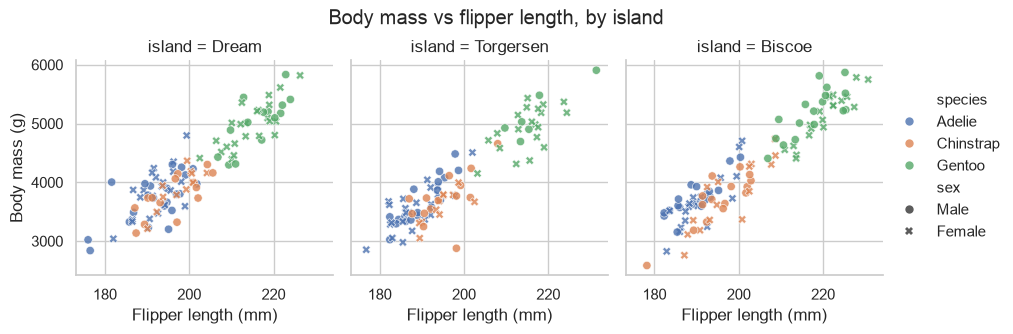

In [4]:
g = sns.relplot(
    data=penguins,
    x="flipper_len_mm", y="body_mass_g",
    hue="species", style="sex", col="island",
    kind="scatter", height=3.2, aspect=0.95, alpha=0.8,
)
g.set_axis_labels("Flipper length (mm)", "Body mass (g)")
g.figure.suptitle("Body mass vs flipper length, by island", y=1.04)

# Figure-level returns a FacetGrid; inspect the grid it built.
print("axes grid shape:", g.axes.shape)
print("columns (facets):", [ax.get_title() for ax in g.axes.flat])
plt.show()

### Example 2 — built-in statistical estimation

`barplot` and `lineplot` *aggregate* automatically: `barplot` reduces each category to its mean
and draws a bootstrap 95% confidence interval; here we put it next to a `boxplot` (shows the full
distribution) in a manually composed two-panel figure using the **axes-level** API and `ax=`.

The printed table shows seaborn's bars match a plain pandas `groupby().mean()` — the plot is doing
the aggregation for you.

group means seaborn aggregated for you:
species
Adelie       3695.0
Chinstrap    3743.0
Gentoo       5048.0


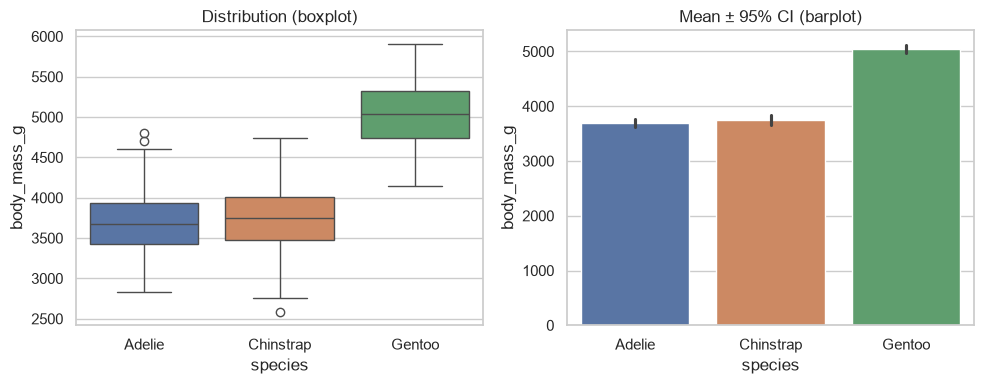

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Axes-level: each draws into a specific subplot via ax=.
sns.boxplot(data=penguins, x="species", y="body_mass_g", hue="species",
            legend=False, ax=axes[0])
axes[0].set_title("Distribution (boxplot)")

sns.barplot(data=penguins, x="species", y="body_mass_g", hue="species",
            legend=False, errorbar=("ci", 95), ax=axes[1])
axes[1].set_title("Mean ± 95% CI (barplot)")

fig.tight_layout()

# The bar heights ARE the group means — confirm against pandas.
means = penguins.groupby("species")["body_mass_g"].mean().round(0)
print("group means seaborn aggregated for you:")
print(means.to_string())
plt.show()

### Example 3 — distribution + correlation heatmap

`histplot` with `kde=True` overlays a smoothed density; `heatmap` renders a correlation matrix
with a diverging palette so the sign of each correlation reads at a glance.

correlation flipper vs mass: 0.927


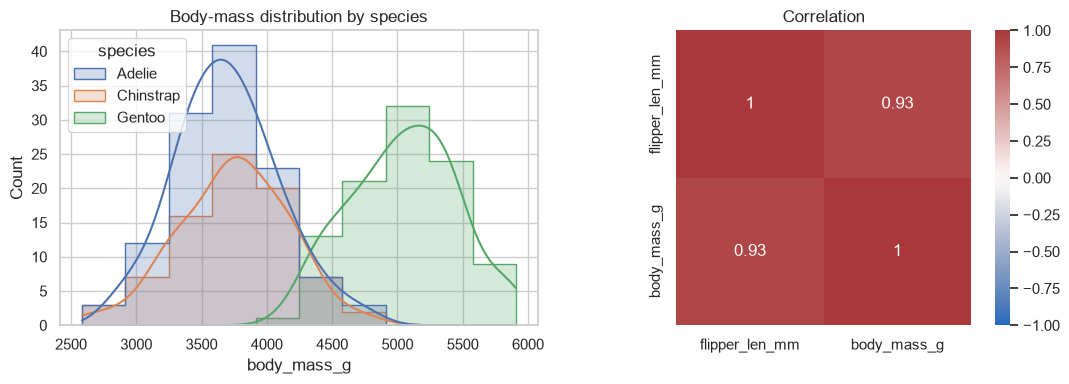

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(data=penguins, x="body_mass_g", hue="species",
             kde=True, element="step", ax=axes[0])
axes[0].set_title("Body-mass distribution by species")

corr = penguins[["flipper_len_mm", "body_mass_g"]].corr()
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="vlag",
            square=True, ax=axes[1])
axes[1].set_title("Correlation")

fig.tight_layout()
print("correlation flipper vs mass: %.3f" % corr.iloc[0, 1])
plt.show()

### Optional — the real built-in datasets (gated; needs network)

seaborn ships ~20 demo datasets fetched from GitHub. We gate the download behind an env var so the
notebook still runs top-to-bottom offline; set `SEABORN_FETCH=1` to pull the genuine `penguins`
frame and confirm the synthetic stand-in above has the same columns.

In [7]:
if os.getenv("SEABORN_FETCH"):
    real = sns.load_dataset("penguins").dropna()
    print("downloaded real penguins:", real.shape)
    print(real.columns.tolist())
else:
    print("Skipping network download (set SEABORN_FETCH=1 to enable).")
    print("Call shape: real = sns.load_dataset('penguins')")

Skipping network download (set SEABORN_FETCH=1 to enable).
Call shape: real = sns.load_dataset('penguins')


## 6. Gotchas & Pitfalls

- **Wide vs long data.** seaborn wants *tidy* (long) data — one column per variable. If you have a
  column per group, `df.melt(...)` it first or the semantic mappings won't line up.
- **Figure-level functions ignore `ax=`.** You can't drop a `relplot`/`catplot` into an existing
  subplot — they create their own figure. Need it inside *your* grid? Use the axes-level twin
  (`scatterplot`, `boxplot`) with `ax=`. This is the #1 source of confusion.
- **`hue` legend duplication in newer versions.** Since v0.14, mapping `x` *and* `hue` to the same
  column warns; pass `legend=False` (as above) or set `hue` to a genuinely different variable.
- **`set_theme()` mutates global rcParams.** It restyles *every* later Matplotlib plot in the
  kernel, not just seaborn ones. Scope it with `with sns.axes_style("whitegrid"):` if that bites.
- **`ci=` is deprecated.** Use `errorbar=("ci", 95)`, `errorbar="sd"`, or `errorbar=None`. The old
  `ci=` / `ci="sd"` keywords are gone in recent versions.
- **Overplotting.** Big scatter plots become ink blobs — reach for `alpha=`, `kind="kde"`, a
  `hexbin`/`histplot(... , bins=...)`, or sampling before you trust the picture.
- **Saving the figure.** Axes-level: `plt.savefig(...)`. Figure-level: `g.savefig(...)` /
  `g.figure.savefig(...)` — calling `plt.savefig` may grab the wrong (empty) figure.
- **Color != meaning.** Don't put a *sequential* palette on categorical `hue` (implies an order)
  or a *qualitative* palette on a continuous variable. Match palette type to data type.

## 7. When to Use vs Alternatives

| Tool | Best at | Trade-off vs seaborn |
|------|---------|----------------------|
| **seaborn** | Fast statistical EDA on tidy DataFrames; great defaults, built-in aggregation/CIs | Static images; limited interactivity; less control than raw Matplotlib |
| **Matplotlib** | Total pixel-level control, custom/bespoke figures, non-statistical art | Verbose; you hand-roll grouping, stats, legends, styling |
| **pandas `.plot()`** | One-liner throwaway charts straight off a DataFrame | Thin Matplotlib wrapper; no statistical estimation or palettes |
| **Plotly / Bokeh** | Interactive, zoomable, hover-able web/dashboard charts | Heavier, JS-backed; overkill for a quick static EDA look |
| **Altair / `seaborn.objects`** | Declarative grammar-of-graphics; composable layered specs | Different mental model; Altair renders via Vega-Lite (web) |

**Rule of thumb:** start in seaborn for exploration. Stay if a static statistical chart is the
deliverable — then reach *down* to the returned Matplotlib `Axes` for final polish. Move *out* to
Plotly/Altair only when interactivity or a web dashboard is an actual requirement.

seaborn and Matplotlib are not rivals — seaborn *is* Matplotlib with a statistical front end, so
"seaborn vs Matplotlib" is really "high-level mapping vs low-level drawing," and you mix both.

## 8. Resources

- **Official docs & user guide** — https://seaborn.pydata.org/
- **Example gallery** (copy-paste recipes for every plot type) — https://seaborn.pydata.org/examples/index.html
- **API reference** — https://seaborn.pydata.org/api.html
- **"Overview of seaborn plotting functions"** (figure- vs axes-level explained) — https://seaborn.pydata.org/tutorial/function_overview.html
- **The `seaborn.objects` interface tutorial** (the newer grammar-of-graphics API) — https://seaborn.pydata.org/tutorial/objects_interface.html
- **Hadley Wickham, "Tidy Data"** (the data shape seaborn assumes) — https://vita.had.co.nz/papers/tidy-data.pdf